In [1]:
from DMDcPlotter import DMDcPlotter
from DMDcDataset import DMDcDataset
import matplotlib.pyplot as plt
import os
import numpy as np
from TimeDelayedDMDc import TimeDelayedDMDc
from GroupedBasis import GroupedBasis
#import importlib
#importlib.reload(DMDcPlotter)

Refer to the installation instructions at https://github.com/FlowModelingControl/flowtorch
If you are not using the TecplotDataloader, ignore this warning.


## Compute common basis

In [2]:
ref_dic_list = list()
path = "/home/tanuj/Masters_Thesis/AFC_using_DRL_DMDc/dmdc/signal_library/cylinder2D/data/Random_walk"
reference_dic = {"u_inlet" : 1.0, "start_time": 3, "dim": "2d", "path": path, "signal":"Random walk"}
ref_dic_list.append(reference_dic)

path = "/home/tanuj/Masters_Thesis/AFC_using_DRL_DMDc/dmdc/signal_library/cylinder2D/data/Chirp"
reference_dic = {"u_inlet" : 1.0, "start_time": 3, "dim": "2d", "path": path, "signal":"Chirp"}
ref_dic_list.append(reference_dic)

path = "/home/tanuj/Masters_Thesis/AFC_using_DRL_DMDc/dmdc/signal_library/cylinder2D/data/Chirp_with_varying_ampl"
reference_dic = {"u_inlet" : 1.0, "start_time": 3, "dim": "2d", "path": path, "signal":"Chirp with varying ampl"}
ref_dic_list.append(reference_dic)

path = "/home/tanuj/Masters_Thesis/AFC_using_DRL_DMDc/dmdc/signal_library/cylinder2D/data/AM"
reference_dic = {"u_inlet" : 1.0, "start_time": 3, "dim": "2d", "path": path, "signal":"AM"}
ref_dic_list.append(reference_dic)


In [3]:
groupedBasis = GroupedBasis(ref_dic_list)
common_Ur = groupedBasis.compute_basis(svd_rank = 100)
groupedBasis.clear_memory()


Shapes: p: (21250, 901) ux: (21250, 901) uy: (21250, 901) state_matrix: (63750, 901)
Shapes: p: (21250, 901) ux: (21250, 901) uy: (21250, 901) state_matrix: (63750, 901)
Shapes: p: (21250, 901) ux: (21250, 901) uy: (21250, 901) state_matrix: (63750, 901)
Shapes: p: (21250, 901) ux: (21250, 901) uy: (21250, 901) state_matrix: (63750, 901)


## Random Walk

In [4]:
path = "/home/tanuj/Masters_Thesis/AFC_using_DRL_DMDc/dmdc/signal_library/cylinder2D/data/Random_walk"
reference_dic = {"u_inlet" : 1.0, "cyl_radius": 0.05, "cyl_centre": (0.2, 0.2), "signal":"Random walk"}
random_walk = TimeDelayedDMDc(path, reference_dic, start_time=3, start_time_act = 4.0, dim="2d", q = 100, qu = 100, step = 1, stepU = 1, rank_dr = 100, U_dr = common_Ur)


Vertex arrays: (21250,) (21250,)
Shapes: p: (21250, 901) ux: (21250, 901) uy: (21250, 901) state_matrix: (63750, 901)
signal_matrix shape (100, 801)
Delayed matrices shapes: q: 100 step: 1 qu: 100 stepU 1 state_matrix_delayed: (10000, 802) signal_matrix_delayed: (100, 801)


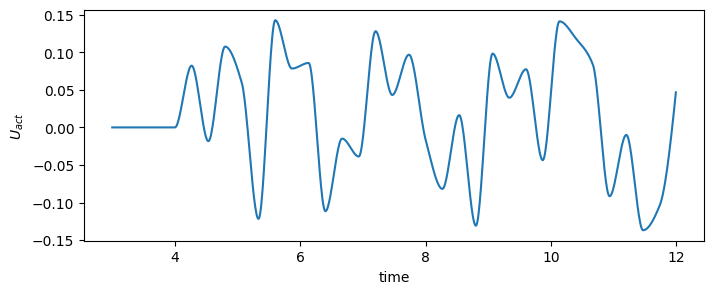

In [5]:
U_act = random_walk.signal_matrix.flatten()
t = np.asarray(random_walk.times_used, dtype=float)[:-1]   # keep your :-1
#t = random_walk.times_used[:-1]
plt.figure(figsize=(8, 3))
plt.plot(t, U_act)
plt.xlabel("time")
plt.ylabel(r"$U_{act}$")
plt.show()

In [6]:
random_walk.makeDMDcModel(svd_rank = 99)
random_walk.clear_memory()


/home/tanuj/Masters_Thesis/AFC_using_DRL_DMDc/env/lib/python3.12/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 4714049.0. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


## Chirp

In [7]:
path = "/home/tanuj/Masters_Thesis/AFC_using_DRL_DMDc/dmdc/signal_library/cylinder2D/data/Chirp"
reference_dic = {"u_inlet" : 1.0, "cyl_radius": 0.05, "cyl_centre": (0.2, 0.2), "signal":"Chirp"}
chirp = TimeDelayedDMDc(path, reference_dic, start_time=3, start_time_act = 4.0, dim="2d", q = 100, qu = 100, step = 1, stepU = 1, rank_dr = 100, U_dr = common_Ur)


Vertex arrays: (21250,) (21250,)
Shapes: p: (21250, 901) ux: (21250, 901) uy: (21250, 901) state_matrix: (63750, 901)
signal_matrix shape (100, 801)
Delayed matrices shapes: q: 100 step: 1 qu: 100 stepU 1 state_matrix_delayed: (10000, 802) signal_matrix_delayed: (100, 801)


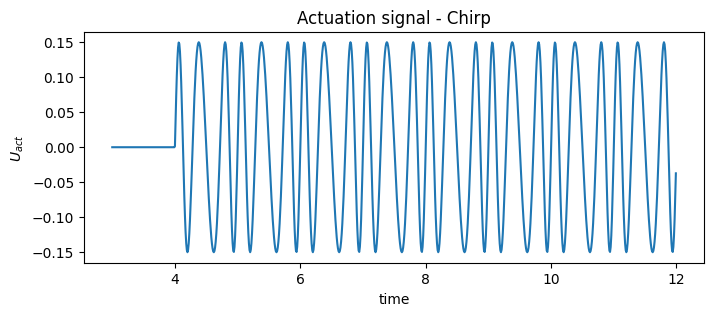

In [8]:
U_act = chirp.signal_matrix.flatten()
t = np.asarray(chirp.times_used, dtype=float)[:-1]   # keep your :-1
#t = random_walk.times_used[:-1]
plt.figure(figsize=(8, 3))
plt.plot(t, U_act)
plt.xlabel("time")
plt.ylabel(r"$U_{act}$")
plt.title("Actuation signal - Chirp")
plt.show()

In [9]:
chirp.makeDMDcModel(svd_rank=100)
chirp.clear_memory()


/home/tanuj/Masters_Thesis/AFC_using_DRL_DMDc/env/lib/python3.12/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 26685324.0. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


## Chirp with varying amplitude

In [10]:
path = "/home/tanuj/Masters_Thesis/AFC_using_DRL_DMDc/dmdc/signal_library/cylinder2D/data/Chirp_with_varying_ampl"
reference_dic = {"u_inlet" : 1.0, "cyl_radius": 0.05, "cyl_centre": (0.2, 0.2), "signal":"Chirp with varying ampl"}
chirp_varying_amp = TimeDelayedDMDc(path, reference_dic, start_time=3, start_time_act = 4.0, dim="2d", q = 100, qu = 100, step = 1, stepU = 1, rank_dr = 100, U_dr = common_Ur)


Vertex arrays: (21250,) (21250,)
Shapes: p: (21250, 901) ux: (21250, 901) uy: (21250, 901) state_matrix: (63750, 901)
signal_matrix shape (100, 801)
Delayed matrices shapes: q: 100 step: 1 qu: 100 stepU 1 state_matrix_delayed: (10000, 802) signal_matrix_delayed: (100, 801)


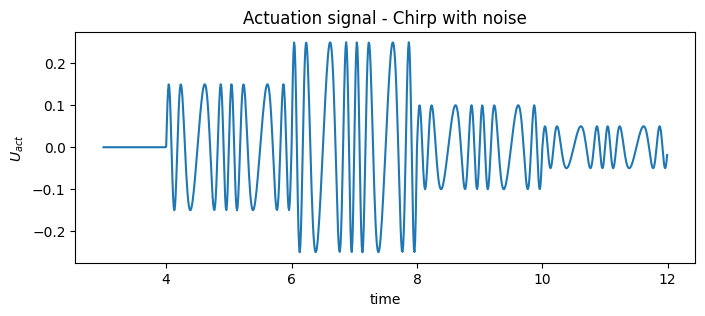

In [11]:
U_act = chirp_varying_amp.signal_matrix.flatten()
t = np.asarray(chirp_varying_amp.times_used, dtype=float)[:-1]   # keep your :-1
#t = random_walk.times_used[:-1]
plt.figure(figsize=(8, 3))
plt.plot(t, U_act)
plt.xlabel("time")
plt.ylabel(r"$U_{act}$")
plt.title("Actuation signal - Chirp with noise")
plt.show()

In [12]:
chirp_varying_amp.makeDMDcModel(svd_rank=96)
chirp_varying_amp.clear_memory()


/home/tanuj/Masters_Thesis/AFC_using_DRL_DMDc/env/lib/python3.12/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 4020422.5. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


## Ampitude Modulated signal

In [13]:
path = "/home/tanuj/Masters_Thesis/AFC_using_DRL_DMDc/dmdc/signal_library/cylinder2D/data/AM"
reference_dic = {"u_inlet" : 1.0, "cyl_radius": 0.05, "cyl_centre": (0.2, 0.2), "signal":"AM"}
AM = TimeDelayedDMDc(path, reference_dic, start_time=3, start_time_act = 4.0, dim="2d", q = 100, qu = 100, step = 1, stepU = 1, rank_dr = 100, U_dr = common_Ur)


Vertex arrays: (21250,) (21250,)
Shapes: p: (21250, 901) ux: (21250, 901) uy: (21250, 901) state_matrix: (63750, 901)
signal_matrix shape (100, 801)
Delayed matrices shapes: q: 100 step: 1 qu: 100 stepU 1 state_matrix_delayed: (10000, 802) signal_matrix_delayed: (100, 801)


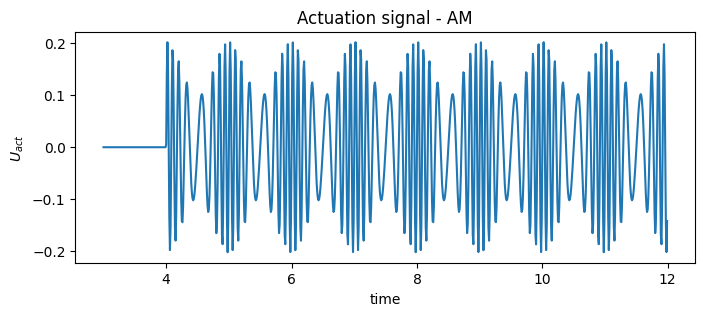

In [14]:
U_act = AM.signal_matrix.flatten()
t = np.asarray(AM.times_used, dtype=float)[:-1]   # keep your :-1
#t = random_walk.times_used[:-1]
plt.figure(figsize=(8, 3))
plt.plot(t, U_act)
plt.xlabel("time")
plt.ylabel(r"$U_{act}$")
plt.title("Actuation signal - AM")
plt.show()


In [15]:
AM.makeDMDcModel(svd_rank=90)
AM.clear_memory()


/home/tanuj/Masters_Thesis/AFC_using_DRL_DMDc/env/lib/python3.12/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 4286320.5. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


# Openloop


In [14]:
"""
path = "/home/tanuj/Masters_Thesis/AFC_using_DRL_DMDc/dmdc/signal_library/cylinder2D/data/Openloop"
reference_dic = {"u_inlet" : 1.0, "cyl_radius": 0.05, "cyl_centre": (0.2, 0.2), "signal":"Openloop"}
openloop = TimeDelayedDMDc(path, reference_dic, start_time=3, start_time_act = 4.0, dim="2d", q = 100, qu = 100, step = 1, stepU = 1, rank_dr = 100)
"""

'\npath = "/home/tanuj/Masters_Thesis/AFC_using_DRL_DMDc/dmdc/signal_library/cylinder2D/data/Openloop"\nreference_dic = {"u_inlet" : 1.0, "cyl_radius": 0.05, "cyl_centre": (0.2, 0.2), "signal":"Openloop"}\nopenloop = TimeDelayedDMDc(path, reference_dic, start_time=3, start_time_act = 4.0, dim="2d", q = 100, qu = 100, step = 1, stepU = 1, rank_dr = 100)\n'

In [15]:
"""
U_act = openloop.signal_matrix.flatten()
t = np.asarray(openloop.times_used, dtype=float)[:-1]   # keep your :-1
#t = random_walk.times_used[:-1]
plt.figure(figsize=(8, 3))
plt.plot(t, U_act)
plt.xlabel("time")
plt.ylabel(r"$U_{act}$")
plt.title("Actuation signal - AM")
plt.show()
"""

'\nU_act = openloop.signal_matrix.flatten()\nt = np.asarray(openloop.times_used, dtype=float)[:-1]   # keep your :-1\n#t = random_walk.times_used[:-1]\nplt.figure(figsize=(8, 3))\nplt.plot(t, U_act)\nplt.xlabel("time")\nplt.ylabel(r"$U_{act}$")\nplt.title("Actuation signal - AM")\nplt.show()\n'

In [16]:
"""
openloop.makeDMDcModel(svd_rank=100)
openloop.clear_memory()
"""

'\nopenloop.makeDMDcModel(svd_rank=100)\nopenloop.clear_memory()\n'

## Compiling Results

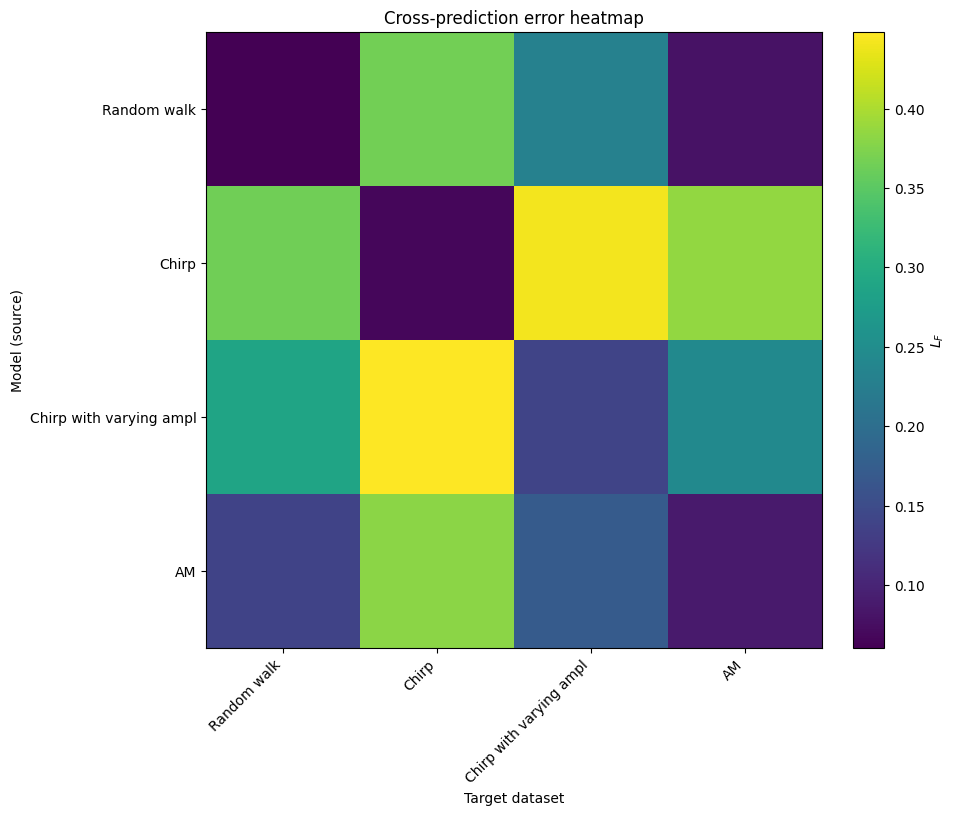

In [16]:
#plotter = DMDcPlotter([random_walk, chirp, chirp_varying_amp])
plotter = DMDcPlotter([random_walk, chirp, chirp_varying_amp, AM])
#plotter = DMDcPlotter([random_walk])
#plotter = DMDcPlotter([random_walk, chirp])
err = plotter.cross_prediction_table()
#print(err)

In [17]:
data = plotter.write_all_fields()

In [18]:
import pickle, gzip
from pathlib import Path

# These are both dicts

# Where to save
out_dir = Path("exports")
out_dir.mkdir(parents=True, exist_ok=True)

# Filenames
data_path = out_dir / "data_new.pkl.gz"

# Save each dict separately (compressed)
with gzip.open(data_path, "wb") as f:
    pickle.dump(data, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved:\n  {data_path}")

Saved:
  exports/data_new.pkl.gz
